In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, brier_score_loss
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

from itertools import product

pd.set_option('display.max_rows', 1000)

# Functions

In [3]:
#Definition of function which produce classification report and confussion matrix for train and also test set 
def class_report(y_train, y_train_pred, y_test, y_test_pred, target_name):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), 
                             gridspec_kw={'height_ratios': [0.5, 1.5]})
    
    #Train classification report
    axes[0, 0].text(-0.2, 0.4, classification_report(y_train, y_train_pred, target_names = target_name), 
                    fontsize=13, family='monospace', va='center')
    axes[0, 0].set_title("Classification Report (Train)", fontsize=14, fontweight='bold')
    axes[0, 0].axis('off') 
    
    #Test classification report
    axes[0, 1].text(-0.2, 0.4, classification_report(y_test, y_test_pred, target_names = target_name), 
                    fontsize=13, family='monospace', va='center')
    axes[0, 1].set_title("Classification Report (Test)", fontsize=14, fontweight='bold')
    axes[0, 1].axis('off') 
    
    # Train Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_train_pred, 
        ax=axes[1, 0], cmap='Blues', normalize='true',
        labels = target_name
    )
    axes[1, 0].set_title("Training Confusion Matrix (Normalized)")
    axes[1, 0].tick_params(axis='x', rotation=90)
    
    # Test Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, 
        ax=axes[1, 1], cmap='Greens', normalize='true',
        labels = target_name
    )
    axes[1, 1].set_title("Testing Confusion Matrix (Normalized)")
    axes[1, 1].tick_params(axis='x', rotation=90)
    
    plt.show()

In [4]:
#Definition of function which produce general calibration curve for train and also test set 
def calibration_curve_general(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    for j, l in zip(range(2), ["train", "test"]):
        ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
        ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")
    
        proba = locals()[f"y_{l}_proba"]
        pred  = locals()[f"y_{l}_pred"]
        true  = locals()[f"y_{l}"]
        
        confidences = np.max(proba, axis=1)
        accuracies = (pred == true).astype(int)
        n_bins = 5
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        bins = np.quantile(confidences, percentiles)
        bin_indices = np.digitize(confidences, bins) - 1
        bin_indices[bin_indices == n_bins] = n_bins - 1
        
        bin_accuracies = []
        bin_confidences = []
        bin_percentages = []
        
        for i in range(n_bins):
            mask = (bin_indices == i)
            if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                bin_accuracies.append(np.mean(accuracies[mask]))
                bin_confidences.append(np.mean(confidences[mask]))
                bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
        ax[j].plot(bin_confidences, bin_accuracies, "bo-", label="Logistic regression")
        
        for b, v, perc in zip(bin_confidences, bin_accuracies, bin_percentages):
            ax[j].annotate(f"{perc:.1f}%", 
                         (b, v), 
                         textcoords="offset points", 
                         xytext=(0, 10), 
                         ha='center',
                         fontsize=10,
                         color="darkblue",
                         fontweight="bold")
        
        ax[j].set_xlabel("Confidence")
        ax[j].set_ylabel("True Accuracy")
        ax[j].set_title(f"Calibration Graph on {l} set")
        ax[j].legend(loc="upper left")
        ax[j].grid(True, alpha=0.5)
        ax[j].set_xlim([-0.05, 1.05])
        ax[j].set_ylim([-0.05, 1.05])
    
    plt.show()

In [5]:
#Definition of function which produce calibration curve per each region for train and also test set 
def calibration_curve_classes(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    for j, a in zip(range(2), ["train", "test"]):
        ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
        ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")
        for l, c in zip(labels, colors):
            proba = locals()[f"y_{a}_proba"]
            pred  = locals()[f"y_{a}_pred"]
            true  = locals()[f"y_{a}"]
        
            subset = (true == l)
            
            confidences = np.max(proba[subset], axis=1)
            accuracies = (pred[subset] == true[subset]).astype(int)
            n_bins = 5
            percentiles = np.linspace(0.0, 1.0, n_bins + 1)
            bins = np.quantile(confidences, percentiles)
            bin_indices = np.digitize(confidences, bins) - 1
            bin_indices[bin_indices == n_bins] = n_bins - 1
            
            bin_accuracies = []
            bin_confidences = []
            bin_percentages = []
            
            for i in range(n_bins):
                mask = (bin_indices == i)
                if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                    bin_accuracies.append(np.mean(accuracies[mask]))
                    bin_confidences.append(np.mean(confidences[mask]))
                    bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
            ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
        
        
        
        ax[j].set_xlabel("Confidence")
        ax[j].set_ylabel("True Accuracy")
        ax[j].set_title(f"Calibration Graph per each class on {a} set")
        ax[j].legend(loc="upper left")
        ax[j].grid(True, alpha=0.5)
        ax[j].set_xlim([-0.05, 1.05])
        ax[j].set_ylim([-0.05, 1.05])
    
    plt.show()

In [6]:
#Definition of function which produce the prediction per one real class for train and also test set 
def predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, region):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['red', 'green', 'blue', 'black']
    for j, a in zip(range(2), ["train", "test"]):
        for l,c in zip(labels, colors):
            proba = locals()[f"y_{a}_proba"]
            pred  = locals()[f"y_{a}_pred"]
            true  = locals()[f"y_{a}"]
        
            subset = (true == region)
            
            confidences = np.max(proba[subset], axis=1)
            accuracies = (pred[subset] == l).astype(int)
            n_bins = 5
            percentiles = np.linspace(0.0, 1.0, n_bins + 1)
            try:
                bins = np.quantile(confidences, percentiles)
                bin_indices = np.digitize(confidences, bins) - 1
                bin_indices[bin_indices == n_bins] = n_bins - 1
                
                bin_accuracies = []
                bin_confidences = []
                bin_percentages = []

                for i in range(n_bins):
                    mask = (bin_indices == i)
                    if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                        bin_accuracies.append(np.mean(accuracies[mask]))
                        bin_confidences.append(np.mean(confidences[mask]))
                        bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
            
                ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
            except Exception as e:
                continue
            
        
        
        ax[j].set_xlabel("Confidence")
        ax[j].set_ylabel("True Accuracy")
        ax[j].set_title(f"Model Predictions for Actual Central Asia Samples ({a} set)")
        ax[j].legend(loc="upper left")
        ax[j].grid(True, alpha=0.5)
        ax[j].set_xlim([-0.05, 1.05])
        ax[j].set_ylim([-0.05, 1.05])
    
    plt.show()

# Data

In [7]:
#Importing data from csv, the path could be different
data = pd.read_csv("database_from_Bitcointalk.csv")
len(data)

4684

In [8]:
#Filtering all the entities which have less than 15 transactions
data = data[data["total"]>=15]
len(data)

1942

In [9]:
data.columns = data.columns.astype(str)
data.head()

,entity,region,0,1,2,3,4,5,6,7,...,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%
0,Entity 0,Central_Asia,0.025191,0.043089,0.042095,0.049718,0.030162,0.050713,0.034803,0.063971,...,0.014584,0.033477,0.043752,0.036460,2993,8.004032,19,-0.965926,2.588190e-01,0.128273
1,Entity 1,East_Asia_Pac,0.006951,0.020854,0.065541,0.069513,0.077458,0.045680,0.049652,0.060576,...,0.009930,0.006951,0.005958,0.007944,983,6.890609,22,-0.500000,8.660254e-01,0.037736
2,Entity 10,Euro_Africa,0.064461,0.054147,0.052858,0.033090,0.026214,0.027503,0.018049,0.015900,...,0.061453,0.055866,0.067039,0.066609,2303,7.741968,8,0.866025,-5.000000e-01,0.091104
3,Entity 100,East_Asia_Pac,0.008368,0.020921,0.029289,0.025105,0.029289,0.071130,0.025105,0.062762,...,0.025105,0.008368,0.020921,0.008368,215,5.370638,23,-0.258819,9.659258e-01,0.066946
4,Entity 1000,Euro_Africa,0.035714,0.107143,0.107143,0.053571,0.053571,0.017857,0.035714,0.053571,...,0.017857,0.035714,0.035714,0.017857,32,3.465736,18,-1.000000,-1.836970e-16,0.107143


In [10]:
X = data
y = data["region"]
col_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]

# Logistic regression

In [11]:
#Preparing test and train set based on selected random state
num = 7736
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = num)

#Scaling variables, which is needed for logistic regression model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[col_names])
X_test_scaled = scaler.transform(X_test[col_names])

#Creating sample weights, which put higher weight on smaller classes and lower weight on bigger classes 
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [12]:
#Defining parameters and training the model of logistic regression
model = LogisticRegression(  
    class_weight = "balanced",
    max_iter=1000
)
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [13]:
#Creating prediction on train and test set
labels = model.classes_
y_train_pred = model.predict(X_train_scaled)
y_train_proba = model.predict_proba(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

## Classification metrics

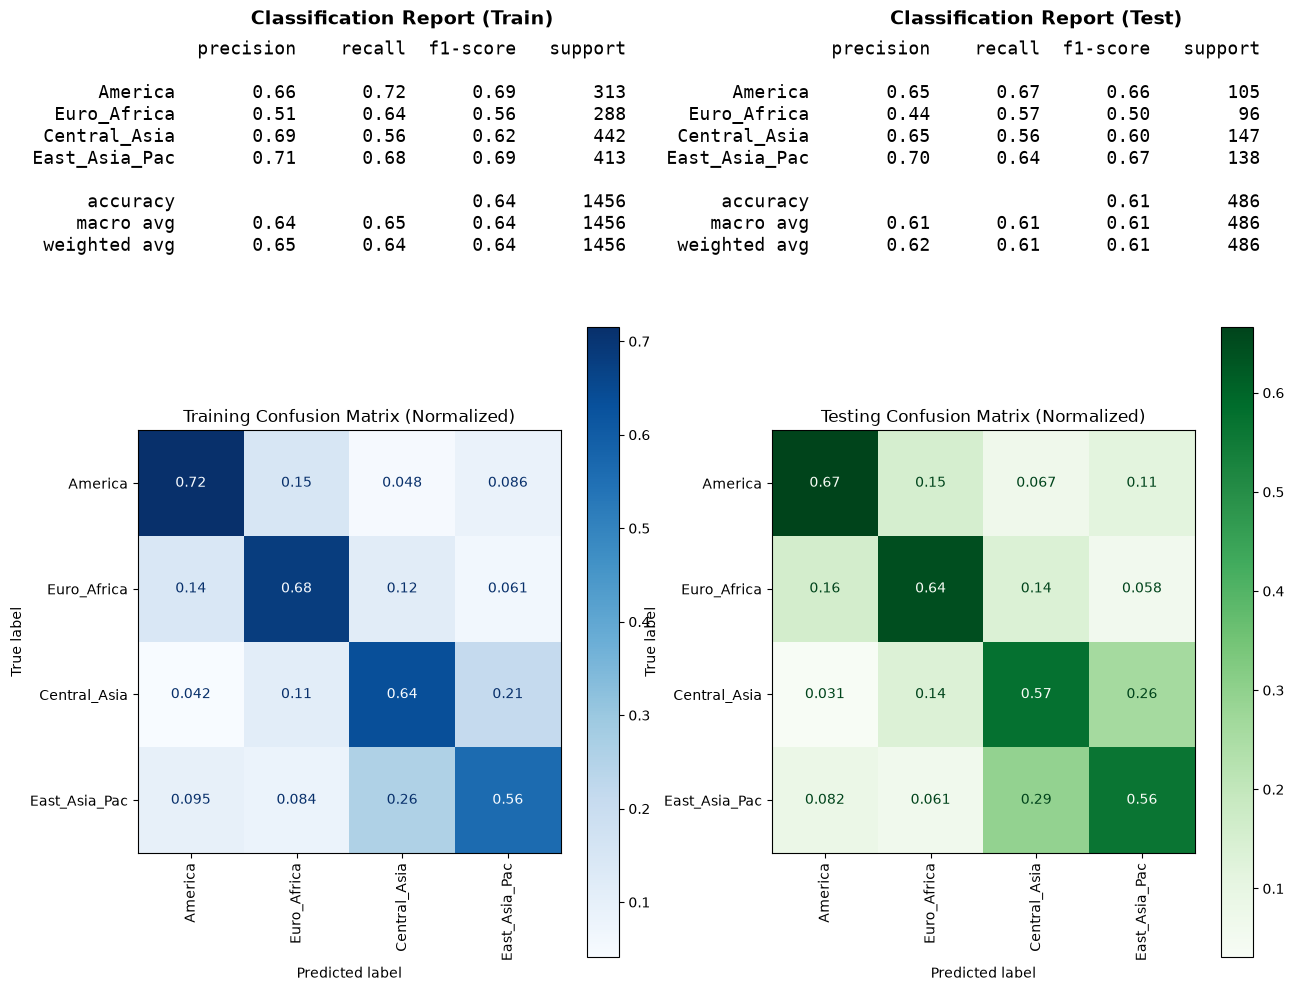

In [14]:
target_names = ["America", "Euro_Africa", "Central_Asia", "East_Asia_Pac"]
class_report(y_train, y_train_pred, y_test, y_test_pred, target_names)

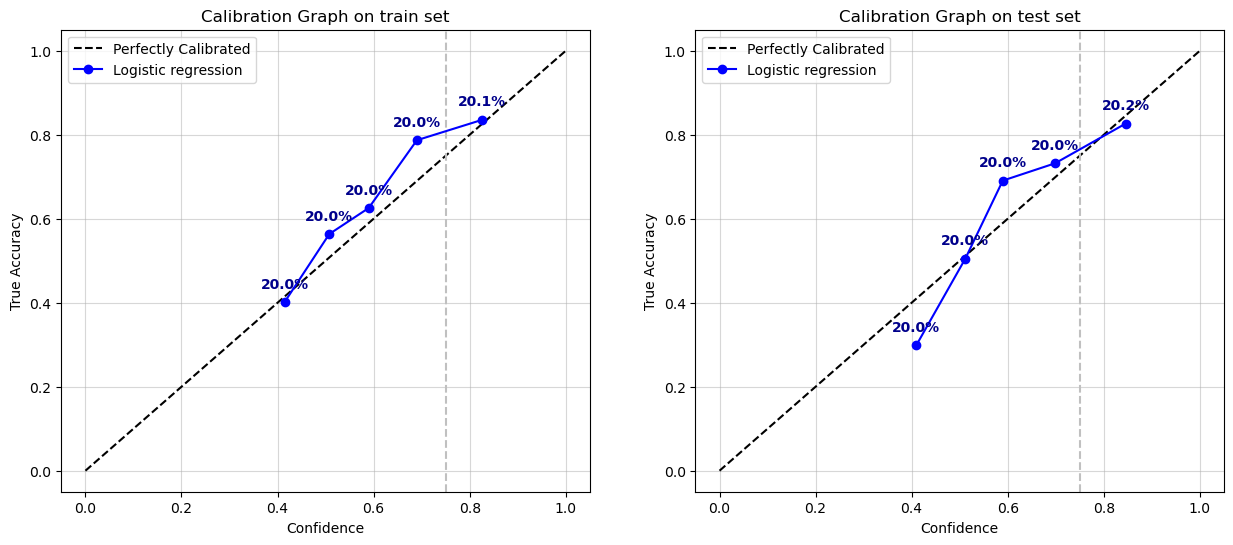

In [14]:
calibration_curve_general(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred)

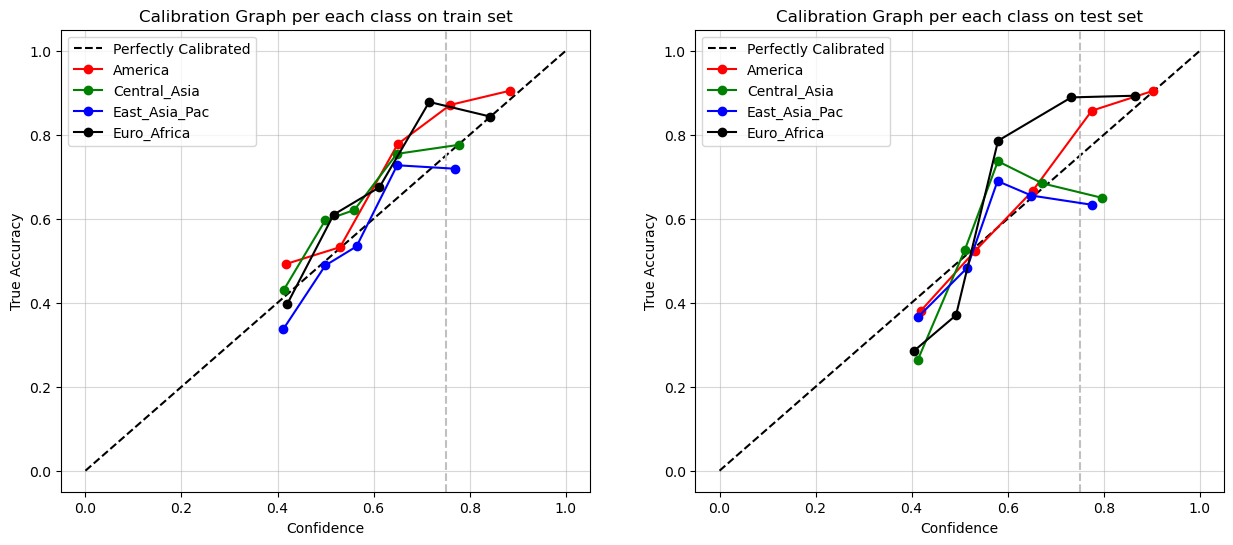

In [15]:
colors = ['red', 'green', 'blue', 'black']
calibration_curve_classes(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels)

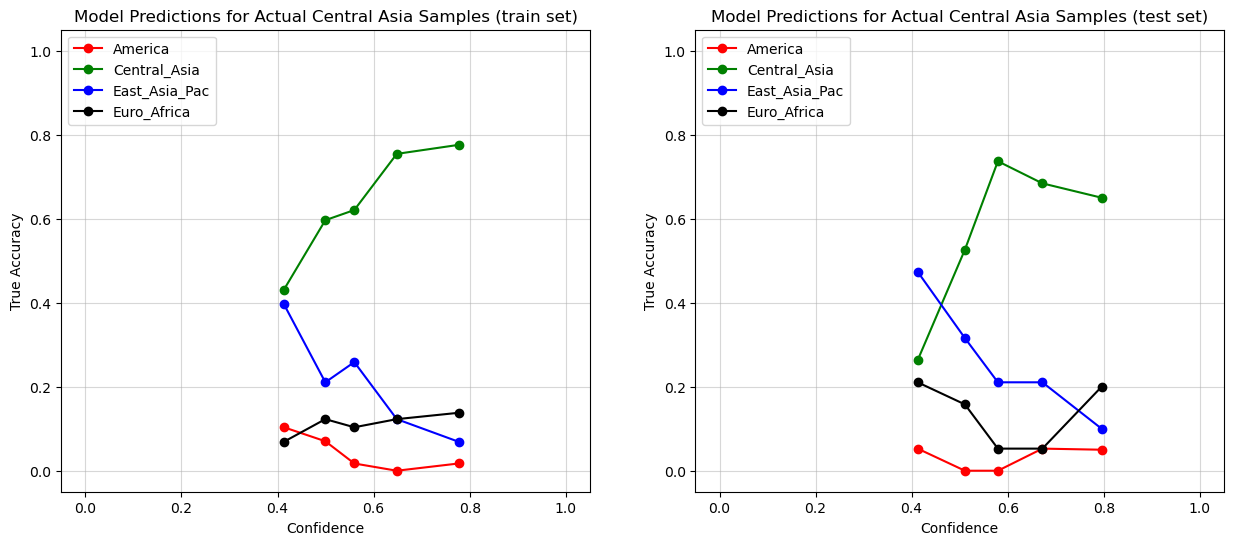

In [16]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "Central_Asia")

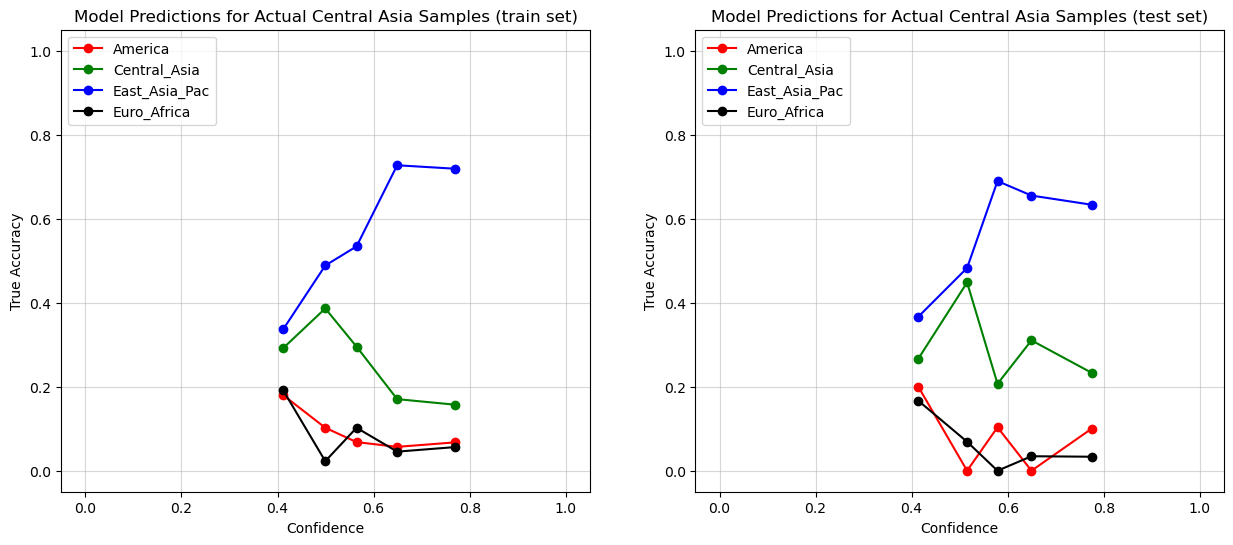

In [17]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "East_Asia_Pac")

# XGBoost

## Parameters fitting

In [14]:
#Defining the function which is used to insert parameter ranges and to find the optimal paarameters
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "eta": trial.suggest_float("eta", 0.01, 0.1),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = xgb.XGBClassifier(
        **param,
    )


    scoring = {
        'brier': 'neg_brier_score',
        'wf1': 'f1_weighted'
    }
    
    cv_results = cross_validate(model, X_train[col_names], y_train_encoded, params={'sample_weight': sample_weights}, cv = 5, scoring=scoring, return_train_score = True)
    brier_test =  cv_results['test_brier'].mean()
    brier_train = cv_results["train_brier"].mean()
    f1_train = cv_results['train_wf1'].mean()
    f1_test = cv_results['test_wf1'].mean()

    trial.set_user_attr("brier_test", brier_test)
    trial.set_user_attr("brier_train", brier_train)
    trial.set_user_attr("f1_train", f1_train)
    trial.set_user_attr("f1_test", f1_test)
    
    
    score = brier_test - 1 * (brier_train-brier_test)
    return score

In [19]:
#Once again making train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = num)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
labels = le.classes_
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [20]:
#Finding optimal parameters
study = optuna.create_study(study_name = "xgboost_study", direction = "maximize")
study.optimize(objective, n_trials = 250, show_progress_bar = True, n_jobs = 1)


[I 2026-05-05 09:17:57,796] A new study created in memory with name: xgboost_study


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-05-05 09:18:01,737] Trial 0 finished with value: -0.5814701996663119 and parameters: {'n_estimators': 552, 'eta': 0.033197638701138274, 'gamma': 3.6341445163789037, 'reg_lambda': 0.5706891673645431, 'max_depth': 8, 'min_child_weight': 20, 'subsample': 0.607470269663238, 'colsample_bytree': 0.8121786944840427}. Best is trial 0 with value: -0.5814701996663119.
[I 2026-05-05 09:18:18,950] Trial 1 finished with value: -0.9211310832234956 and parameters: {'n_estimators': 801, 'eta': 0.01113244893644683, 'gamma': 0.11447381980252969, 'reg_lambda': 3.321243413934794, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.9963507076635463, 'colsample_bytree': 0.6685444482842414}. Best is trial 0 with value: -0.5814701996663119.
[I 2026-05-05 09:18:23,346] Trial 2 finished with value: -0.6946164706237854 and parameters: {'n_estimators': 693, 'eta': 0.07577656336199273, 'gamma': 1.9598042095309314, 'reg_lambda': 3.2662873266274453, 'max_depth': 4, 'min_child_weight': 15, 'subsample': 0.74

In [22]:
#Best parameters
best_params = study.best_params
best_params

{'n_estimators': 728,
 'eta': 0.014933929362161301,
 'gamma': 4.823264186630793,
 'reg_lambda': 2.0288532309315066,
 'max_depth': 2,
 'min_child_weight': 18,
 'subsample': 0.6000283178227324,
 'colsample_bytree': 0.7738601757001992}

In [23]:
#Printig the observed metrics for each iteration in process of finding parameters, used to manually check the level of overfitting
df = study.trials_dataframe()
print(df[['value', 'user_attrs_brier_train', 'user_attrs_brier_test', 'user_attrs_f1_train', 'user_attrs_f1_test']])

        value  user_attrs_brier_train  user_attrs_brier_test  \
0   -0.581470               -0.400683              -0.491076   
1   -0.921131               -0.068062              -0.494596   
2   -0.694616               -0.300360              -0.497488   
3   -0.606156               -0.399042              -0.502599   
4   -0.601314               -0.391194              -0.496254   
5   -0.638873               -0.340387              -0.489630   
6   -0.685920               -0.299236              -0.492578   
7   -0.599719               -0.383095              -0.491407   
8   -0.663437               -0.326347              -0.494892   
9   -0.595747               -0.383420              -0.489584   
10  -0.566862               -0.438845              -0.502854   
11  -0.565483               -0.434224              -0.499853   
12  -0.570095               -0.432698              -0.501396   
13  -0.571494               -0.434483              -0.502989   
14  -0.595350               -0.403261   

In [24]:
#Training the model on best parameters and printing the results of crossvalidation
model = xgb.XGBClassifier(
    n_estimators= 211,              
    eta= 0.038741570723655985,
    gamma = 4.998847340927335,
    reg_lambda =3.316876517397734,
    max_depth = 2,
    min_child_weight= 19,           
    subsample =0.63506725808971654,
    colsample_bytree=0.8466734018456014
)
scoring = {
        'brier': 'neg_brier_score',
        'wf1': 'f1_weighted'
    }
cv_results = cross_validate(model, X_train[col_names], y_train_encoded, params={'sample_weight': sample_weights}, cv = 5, scoring=scoring, return_train_score = True)
cv_results

{'fit_time': array([0.26536107, 0.26538157, 0.28464985, 0.26107979, 0.26205492]),
 'score_time': array([0.01410079, 0.01436424, 0.01430559, 0.01403856, 0.01439285]),
 'test_brier': array([-0.48136653, -0.50192856, -0.48818303, -0.50936284, -0.53344801]),
 'train_brier': array([-0.45633268, -0.45177422, -0.45716196, -0.45053423, -0.44062955]),
 'test_wf1': array([0.67786302, 0.62768398, 0.67033134, 0.62171606, 0.6062682 ]),
 'train_wf1': array([0.68500247, 0.69972433, 0.68306478, 0.69655992, 0.71136977])}

## Model

In [12]:
#Defining train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = num)

#Encoding labels for XGBoost model, beccause the input must be in integers not in string values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
labels = le.classes_

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [13]:
model = xgb.XGBClassifier(
    n_estimators= 211,              
    eta= 0.038741570723655985,
    gamma = 4.998847340927335,
    reg_lambda =3.316876517397734,
    max_depth = 2,
    min_child_weight= 19,           
    subsample =0.63506725808971654,
    colsample_bytree=0.8466734018456014
)

In [14]:
model.fit(X_train[col_names], y_train_encoded, sample_weight = sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8466734018456014
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.data

In [15]:
#Predictions on train and test set
y_train_pred = model.predict(X_train[col_names])
y_train_pred = le.inverse_transform(y_train_pred)
y_train_proba = model.predict_proba(X_train[col_names])

y_test_pred = model.predict(X_test[col_names])
y_test_pred = le.inverse_transform(y_test_pred)
y_test_proba = model.predict_proba(X_test[col_names])

In [29]:
#Visualising decision trees for selected tree in XGBoost 
visual = xgb.to_graphviz(model, num_trees=4)
visual

ImportError: You must install graphviz to plot tree

## Classification metrics

In [40]:
class_report(y_train, y_train_pred, y_test, y_test_pred, target_names)

NameError: name 'target_names' is not defined

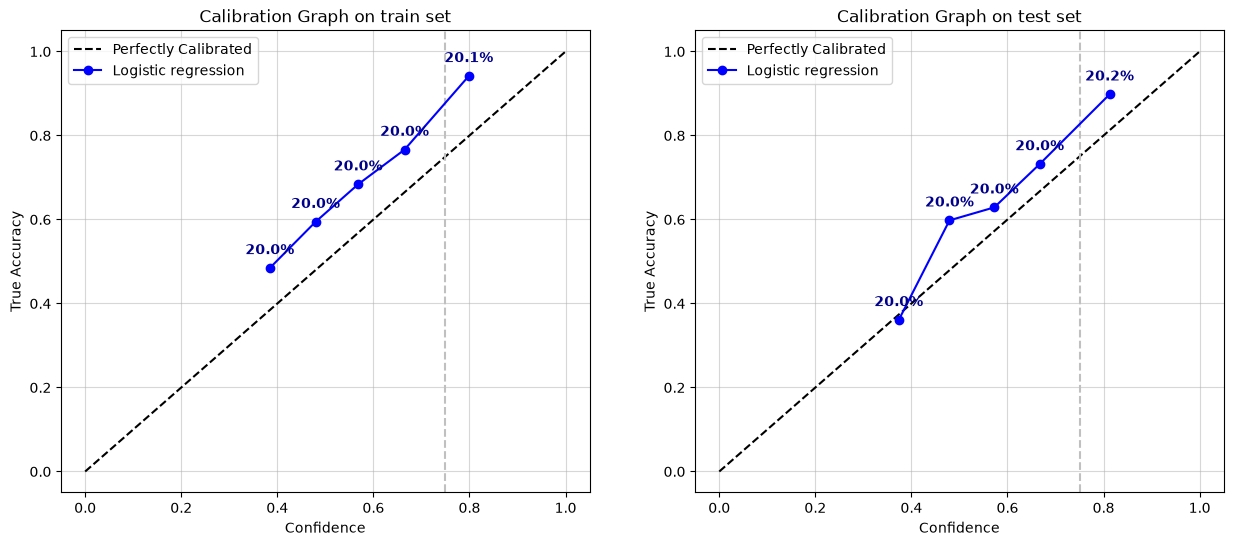

In [41]:
calibration_curve_general(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred)

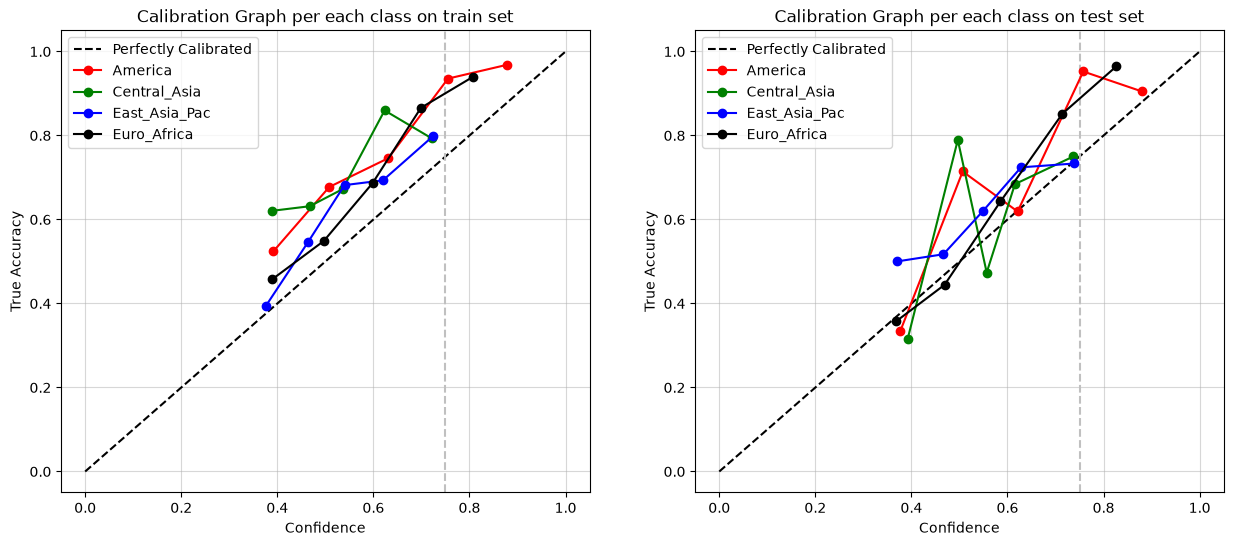

In [24]:
colors = ['red', 'green', 'blue', 'black']
calibration_curve_classes(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels)

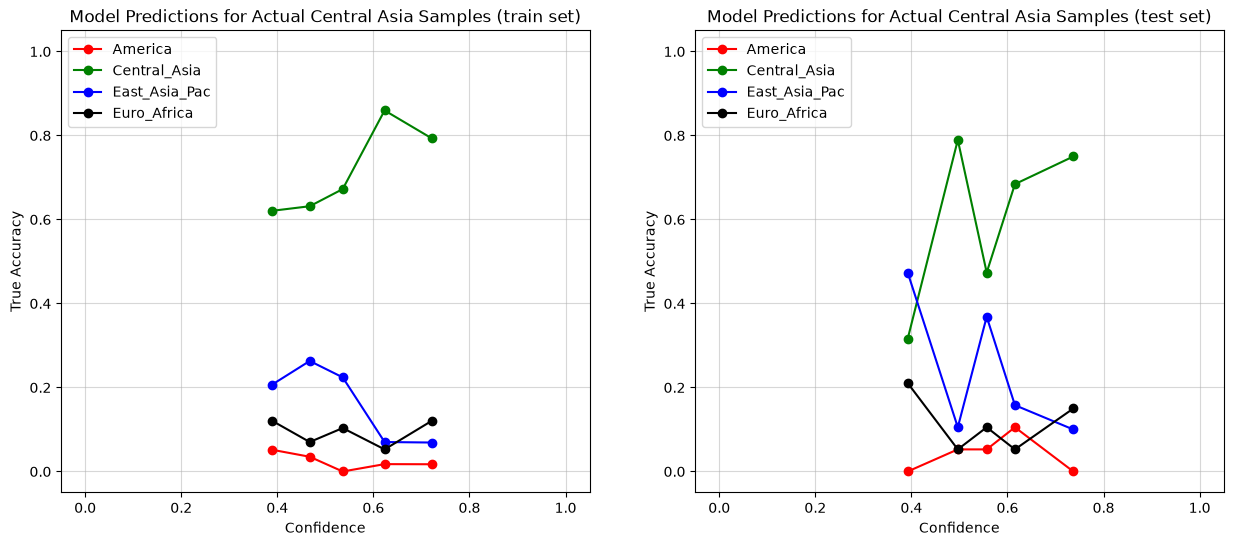

In [25]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "Central_Asia")

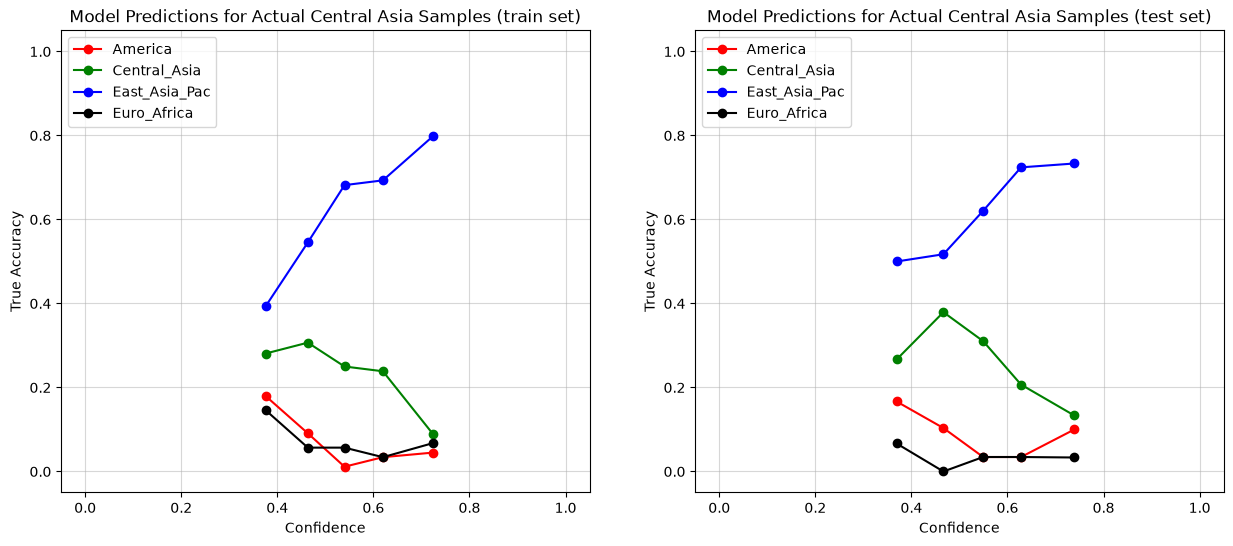

In [26]:
predictions_region(y_train, y_train_proba, y_train_pred, y_test, y_test_proba, y_test_pred, colors, labels, "East_Asia_Pac")

# Model deployment

In [18]:
import pickle

In [19]:
# When saving:
data_to_save = {
    "model": model,
    "encoder": le  # Your LabelEncoder instance
}
with open('timezone_model.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

In [20]:
row = [0.02519058667550547,0.04308916141862778,0.04209479615512098,0.04971826317533974,0.030162412993039442,0.05071262843884654,0.03480278422273782,0.06397083195227046,0.0765661252900232,0.08485250248591315,0.0381173351010938,0.036128604574080216,0.03546569439840901,0.0576731852833941,0.059330460722572094,0.02883659264169705,0.03480278422273782,0.03646005966191581,0.01358965860125953,0.030162412993039442,0.014584023864766324,0.033476963871395427,0.043752071594298975,0.03646005966191581]
y_row = model.predict([row])
y_train_row = le.inverse_transform(y_row)
y_row_proba = model.predict_proba([row])

In [49]:
y_row_proba

array([[0.20185204, 0.18653895, 0.39964795, 0.21196109]], dtype=float32)